In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")

##### Check files in the current folder.

In [2]:
ls

 Volume in drive C has no label.
 Volume Serial Number is 80D1-CA4D

 Directory of C:\Users\ADMIN\Documents\dat\Mi\ML 10-12 New\Day 9 Simple Linear Regression

06-07-2026  10.24 AM    <DIR>          .
06-07-2026  10.24 AM    <DIR>          ..
06-07-2026  10.24 AM    <DIR>          .ipynb_checkpoints
06-07-2026  10.24 AM               337 Simple Linear Regression.ipynb
06-07-2026  10.24 AM             2,349 student_info.csv
               2 File(s)          2,686 bytes
               3 Dir(s)  110,451,449,856 bytes free


# Read file.

In [3]:
df = pd.read_csv("student_info.csv")

# Inspection of data.

In [4]:
df.head()

,hours,marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [5]:
df.tail()

,hours,marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hours   195 non-null    float64
 1   marks   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [7]:
df.describe()

,hours,marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


# Check for missing values.

In [8]:
df.isna().sum()

hours    5
marks    0
dtype: int64

In [10]:
df [ df.duplicated()]

,hours,marks


##### Simple inputer

In [12]:
from sklearn.impute   import SimpleImputer

In [15]:
si = SimpleImputer(missing_values=np.nan,  strategy="median")

df['hours'] = si.fit_transform(  df[[  "hours"]])

##### check for missing value again.

In [16]:
df.isna().sum()

hours    0
marks    0
dtype: int64

# Outlier.

<Axes: xlabel='hours'>

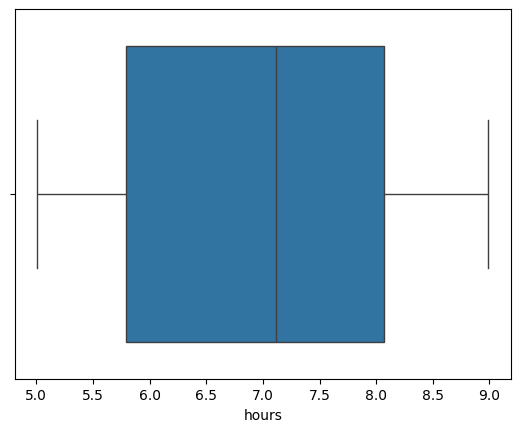

In [18]:
sns.boxplot(data=df, x="hours")

<Axes: xlabel='marks'>

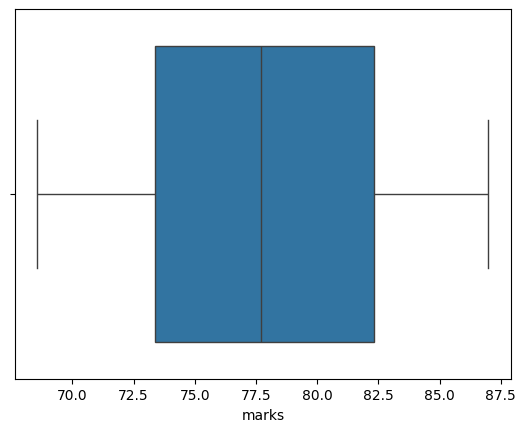

In [19]:
sns.boxplot(data=df, x="marks")

# Skewness.

In [20]:
from scipy.stats import skew

In [22]:
print(skew(df['hours']))

-0.0691026239648271


In [23]:
print(skew(df["marks"]))

-0.016797356319964114


# Encoding.

In [24]:
df.head()

,hours,marks
0,6.83,78.50
1,6.56,76.74
2,7.12,78.68
3,5.67,71.82
4,8.67,84.19


# standarscaler

In [25]:
df.describe()

,hours,marks
count,200.00000,200.00000
mean,6.99905,77.93375
std,1.23737,4.92570
min,5.01000,68.57000
25%,5.79000,73.38500
50%,7.12000,77.71000
75%,8.07250,82.32000
max,8.99000,86.99000


# Divide data into features and Response.

In [32]:
x = df.iloc[ : ,  0:1]  # 2D
y = df.iloc[ : ,  -1]   # 1D

In [33]:
y.ndim

1

In [34]:
y

0      78.50
1      76.74
2      78.68
3      71.82
4      84.19
       ...  
195    81.67
196    84.68
197    86.75
198    78.05
199    83.50
Name: marks, Length: 200, dtype: float64

### Divide the data into train and test.

In [35]:
from sklearn.model_selection  import train_test_split

In [44]:
xtrain, xtest,    ytrain, ytest      =  train_test_split( x, y,     test_size=0.2,  random_state=42)

# Model preparation / model selection

In [47]:
# Step 1 : Import the model.
from sklearn.linear_model    import LinearRegression

# step 2 : make an object of a model.
linreg =   LinearRegression()


# step 3 : train the model.
linreg.fit(xtrain, ytrain)


# step 4 : predict using model.
yp = linreg.predict(xtest)

# model evaluation.

##### how bad out model is.

- mean abosulte error
- mean square error
- root mean square error.

In [48]:
yp

array([74.33836372, 76.14284387, 82.3408409 , 79.98717114, 75.47597077,
       73.16152884, 82.81157485, 70.80785908, 71.59241566, 74.69141418,
       81.28168951, 84.41991585, 71.55318783, 70.41558078, 85.24370027,
       73.16152884, 73.00461752, 82.14470175, 76.57434999, 70.33712512,
       84.53759934, 75.39751511, 83.007714  , 81.43860082, 71.82778264,
       71.98469396, 77.43736223, 82.85080268, 84.77296632, 77.24122309,
       76.92740045, 83.43922012, 84.53759934, 74.14222457, 71.59241566,
       78.81033626, 83.12539749, 70.61171993, 81.32091734, 70.49403644])

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [55]:
mae = mean_absolute_error(ytest, yp)

mse = mean_squared_error(ytest, yp)

rmse = root_mean_squared_error(ytest, yp)


In [56]:
print(f"Mean absolute Error is {mae}")
print(f"Mean square Error  is {mse}")
print(f"Root mean Square Error is { rmse }")

Mean absolute Error is 0.987019143212984
Mean square Error  is 1.4566714653285486
Root mean Square Error is 1.2069264539848932


### how good our model is 

In [57]:
from sklearn.metrics  import r2_score

In [58]:
r2 = r2_score(ytest, yp)

In [59]:
print("Peformace is ", r2)

Peformace is  0.9424791244450514


# Use visulaization for evaluation.

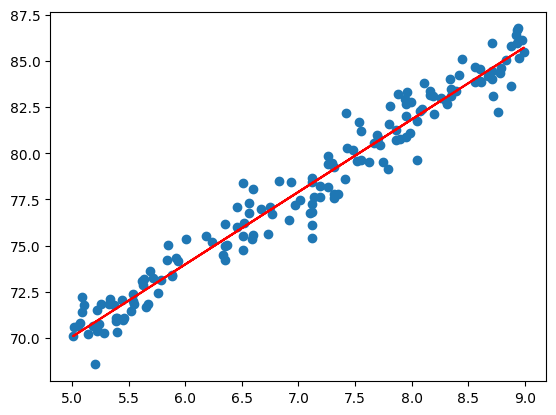

In [62]:
plt.scatter(xtrain, ytrain)
plt.plot(   xtrain, linreg.predict(xtrain), color="red")

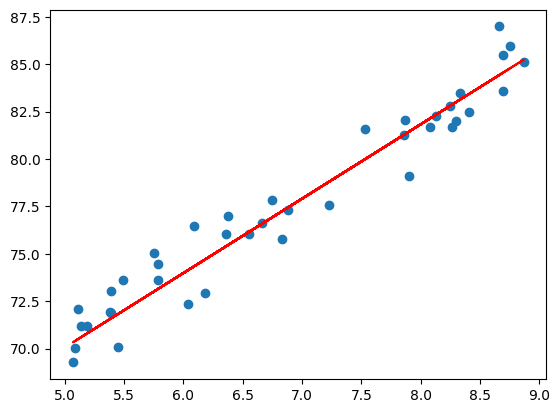

In [64]:
plt.scatter(xtest, ytest)
plt.plot( xtest,   yp, color="red")

#### check for coefficient.

In [65]:
linreg.coef_   # 

array([3.92278293])

In [66]:
linreg.intercept_

np.float64(50.44861565293157)

# Prediction.

In [67]:
df.head()

,hours,marks
0,6.83,78.50
1,6.56,76.74
2,7.12,78.68
3,5.67,71.82
4,8.67,84.19


In [69]:
xtest.ndim

2

In [72]:
hour = int(input("Enter number of hours you study "))

ypp = linreg.predict( [[hour]])
print("You will score ", ypp[0])

Enter number of hours you study  3


You will score  62.216964452392


In [76]:
def predictors(hour):
    ypp = linreg.predict( [[ hour ]] )

    return f'Your score will be {ypp[0]}'

In [77]:
predictors(4)

'Your score will be 66.13974738554548'

# The end.